In [1]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)



In [3]:
# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("heart.csv")



In [4]:
# -----------------------------
# Data Inspection
# -----------------------------
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())



   age     sex              cp  trestbps   chol    fbs         restecg  \
0   63    Male  typical angina     145.0  233.0   True  lv hypertrophy   
1   67    Male    asymptomatic     160.0  286.0  False  lv hypertrophy   
2   67    Male    asymptomatic     120.0  229.0  False  lv hypertrophy   
3   37    Male     non-anginal     130.0  250.0  False          normal   
4   41  Female  typical angina     130.0  204.0  False  lv hypertrophy   

   thalch  exang  oldpeak  num  
0   150.0  False      2.3    0  
1   108.0   True      1.5    2  
2   129.0   True      2.6    1  
3   187.0  False      3.5    0  
4   172.0  False      1.4    0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    object 
 2   cp        918 non-null    object 
 3   trestbps  918 non-null    float64
 4 

In [5]:
# -----------------------------
# Check Missing Values
# -----------------------------
print("\nMissing Values:")
print(df.isnull().sum())




Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
num         0
dtype: int64


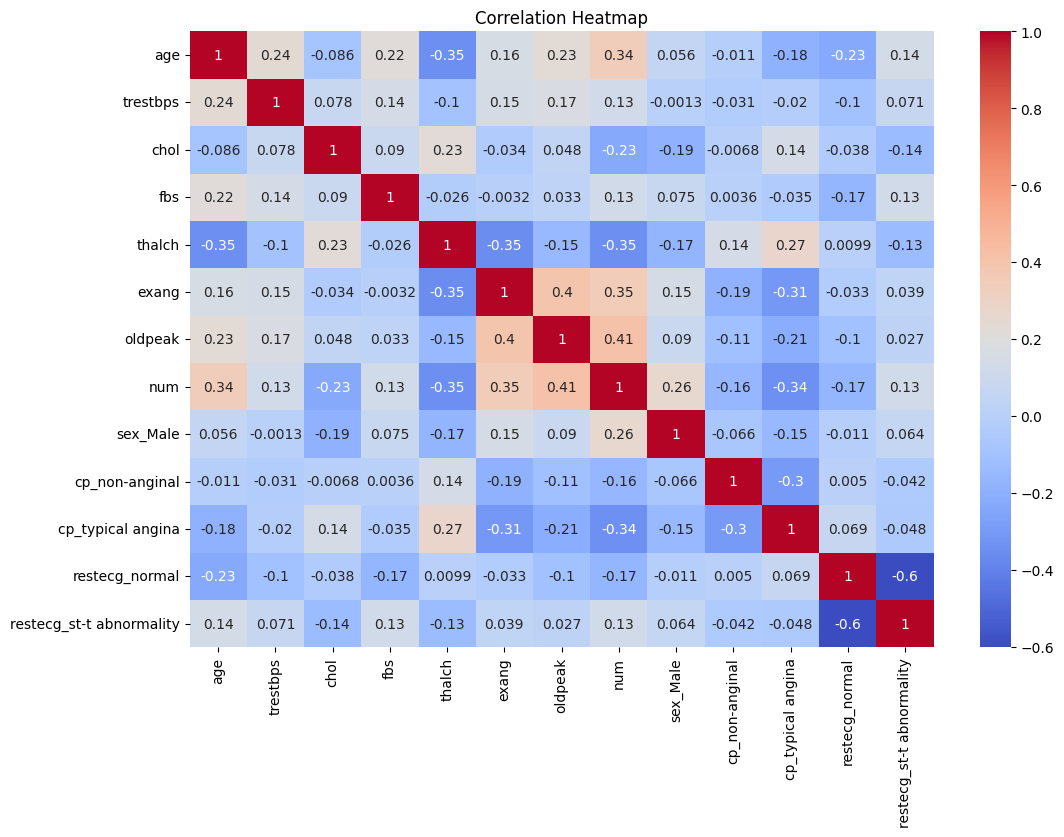

In [8]:
# -----------------------------
# EDA - Correlation Heatmap
# -----------------------------
# Convert categorical string variables to numerical using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['sex', 'cp', 'restecg'], drop_first=True)

plt.figure(figsize=(12,8))

sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

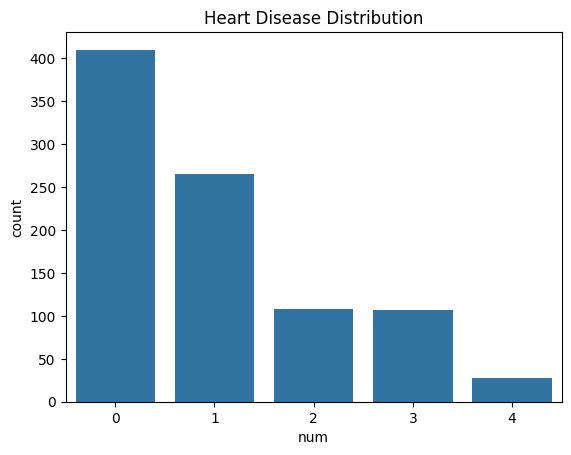

In [10]:
# -----------------------------
# Target Distribution
# -----------------------------
sns.countplot(x='num', data=df)

plt.title("Heart Disease Distribution")
plt.show()

In [15]:
# -----------------------------
# Features and Target
# -----------------------------
# Define features (X) and target (y)
X = df.drop('num', axis=1)
y = df['num']

# Convert categorical features in X to numerical using one-hot encoding
X = pd.get_dummies(X, columns=['sex', 'cp', 'restecg', 'fbs', 'exang'], drop_first=True)

In [17]:
# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [18]:
# -----------------------------
# Train Logistic Regression
# -----------------------------
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
# -----------------------------
# Accuracy
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)




Accuracy: 0.5706521739130435


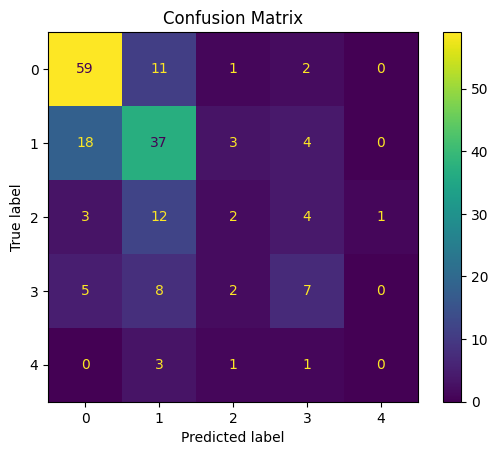

In [20]:
# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")
plt.show()



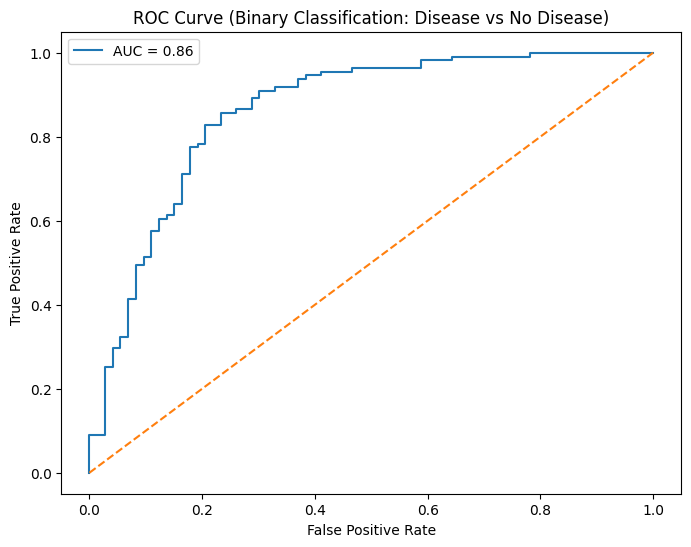

In [22]:
# -----------------------------
# ROC Curve
# -----------------------------
# Convert multi-class y_test to binary (0: no disease, 1: disease present)
y_test_binary = (y_test > 0).astype(int)

# Get probabilities for all classes
probabilities = model.predict_proba(X_test)

# Calculate y_prob for the positive class (disease present) for the binary problem
# This is 1 - probability of class 0 (no disease)
# Assuming class 0 is at index 0 in model.classes_
if 0 in model.classes_:
    no_disease_class_index = model.classes_.tolist().index(0)
    y_prob = 1 - probabilities[:, no_disease_class_index]
else:
    # If 0 is not a class, or if all other classes are considered 'disease',
    # we need a different aggregation. For now, we'll assume 0 is no disease.
    # As a fallback, take the max probability of any positive class
    y_prob = probabilities[:, 1:].sum(axis=1) # Sum probabilities of classes 1,2,3,4


fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob)

auc_score = roc_auc_score(y_test_binary, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary Classification: Disease vs No Disease)")
plt.legend()

plt.show()


Feature Importance:
                     Feature  Importance
7          cp_typical angina    1.305802
6             cp_non-anginal    0.938141
8             restecg_normal    0.259056
9   restecg_st-t abnormality    0.062016
3                     thalch    0.021233
2                       chol    0.004072
1                   trestbps   -0.000478
0                        age   -0.028971
10                  fbs_True   -0.515112
4                    oldpeak   -0.675310
11                exang_True   -0.732785
5                   sex_Male   -0.852183


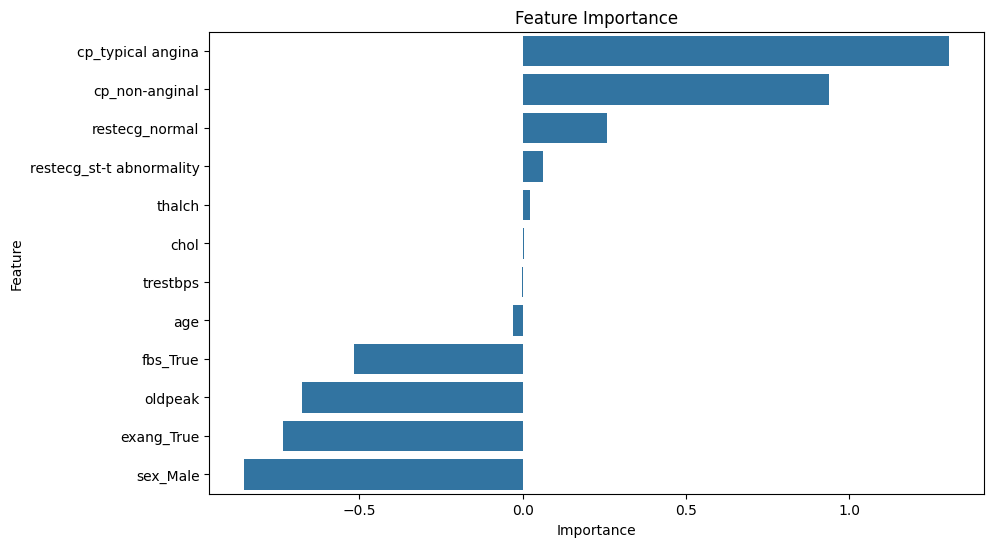

In [23]:
# -----------------------------
# Feature Importance
# -----------------------------
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

importance = importance.sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importance)

# Plot Feature Importance
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()